# Chapter 147 — NumPy Vector Operations

> **Prerequisites:** ch146 (Vectorization), ch123 (Vectors in Programming), ch128 (Norms), ch131 (Dot Product)  
> **You will learn:**
> - The essential NumPy API for vector and array operations
> - Array creation, indexing, slicing, and reshaping patterns
> - Reduction operations: sum, mean, max, argmax, norm along axes
> - The most important NumPy functions for linear algebra
> - Common pitfalls: copies vs views, dtype issues, axis conventions
>
> **Environment:** Python 3.x, numpy

---

## 1. Concept

NumPy is the numerical foundation of scientific Python. Every major ML library — PyTorch, TensorFlow, scikit-learn, pandas — either wraps NumPy arrays or replicates their interface. Understanding NumPy's array model thoroughly is not optional; it is the layer everything else runs on.

The core object is `np.ndarray`: a contiguous block of typed memory with a shape (tuple of dimensions) and a stride (how many bytes to advance per index in each dimension). Understanding shape and stride is the key to understanding all of NumPy's behavior.

This chapter is a structured reference for the operations used throughout this book. It consolidates patterns introduced earlier into a single, systematic survey.

**Common misconceptions:**
- "`a[:]` makes a copy." Wrong — it returns a view. `a.copy()` makes a copy.
- "Indexing with an integer reduces rank; indexing with a slice does not." Correct — `a[0]` drops a dimension; `a[0:1]` keeps it.
- "All NumPy operations create new arrays." Wrong — many operations return views. Modifying a view modifies the original.

---

## 2. Intuition & Mental Models

**Shape is the primary mental model.** Before calling any NumPy function, ask: *what shape goes in, what shape comes out?* Track shapes through every operation. This one habit prevents most NumPy bugs.

**Axis = dimension index.** `axis=0` means "collapse along the first dimension" (rows). `axis=1` means "collapse along the second" (columns). For a (3, 4) matrix: `sum(axis=0)` gives a (4,) vector (sum down each column); `sum(axis=1)` gives a (3,) vector (sum across each row).

**View vs copy.** Most slicing and reshaping returns views — no data copied, just different indexing. This is efficient but dangerous: modifying `b = a[0:3]` also modifies `a`. Use `.copy()` when independence is needed.

**Dtype matters.** `np.array([1, 2, 3])` has dtype `int64`. Dividing by a scalar gives floats. But `np.zeros((3,3), dtype=int)` will silently truncate float assignments. Always use `dtype=float` for numerical arrays unless you specifically need integers.

---

## 3. Visualization

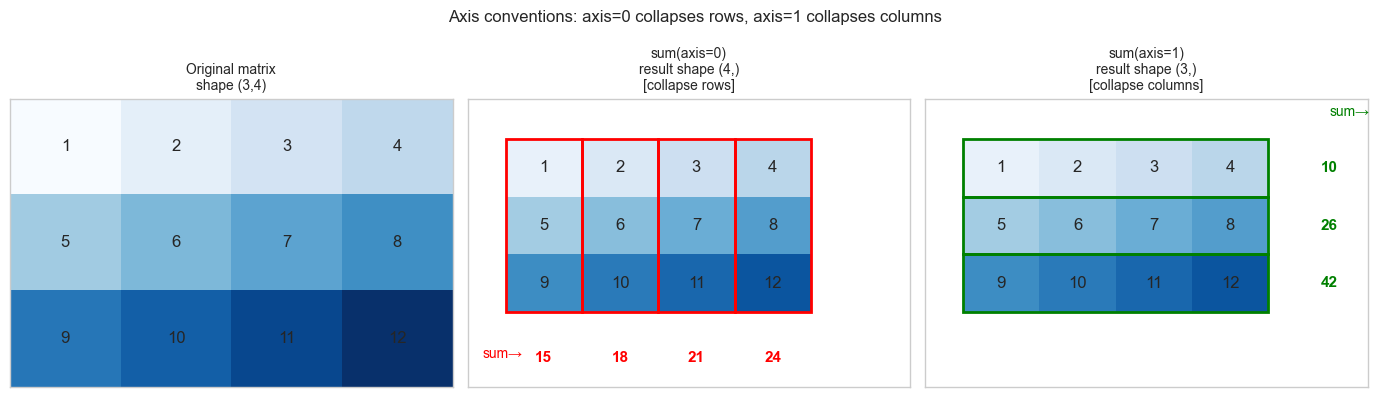

In [5]:
# --- Visualization: axis conventions for reductions ---

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

plt.style.use('seaborn-v0_8-whitegrid')

A = np.array([[1, 2, 3, 4],
              [5, 6, 7, 8],
              [9,10,11,12]], dtype=float)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

def draw_matrix_with_highlight(ax, M, highlight_axis, title, result):
    rows, cols = M.shape
    ax.imshow(M, cmap='Blues', vmin=0, vmax=M.max()+2, aspect='auto')
    for i in range(rows):
        for j in range(cols):
            ax.text(j, i, f'{M[i,j]:.0f}', ha='center', va='center', fontsize=12)

    if highlight_axis == 0:  # collapse rows -> highlight columns
        for j in range(cols):
            rect = patches.Rectangle((j-0.5, -0.5), 1, rows, lw=2,
                                      edgecolor='red', facecolor='none')
            ax.add_patch(rect)
        for j, val in enumerate(result):
            ax.text(j, rows+0.3, f'{val:.0f}', ha='center', va='center',
                    fontsize=11, color='red', fontweight='bold')
        ax.text(-0.8, rows+0.3, 'sum→', fontsize=10, color='red')
    else:  # collapse cols -> highlight rows
        for i in range(rows):
            rect = patches.Rectangle((-0.5, i-0.5), cols, 1, lw=2,
                                      edgecolor='green', facecolor='none')
            ax.add_patch(rect)
        for i, val in enumerate(result):
            ax.text(cols+0.3, i, f'{val:.0f}', ha='center', va='center',
                    fontsize=11, color='green', fontweight='bold')
        ax.text(cols+0.3, -0.9, 'sum→', fontsize=10, color='green')

    ax.set_xlim(-1, cols + 0.8)
    ax.set_ylim(rows + 0.8, -1.2)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=10)

axes[0].imshow(A, cmap='Blues', aspect='auto')
for i in range(3):
    for j in range(4):
        axes[0].text(j, i, f'{A[i,j]:.0f}', ha='center', va='center', fontsize=12)
axes[0].set_xticks([]); axes[0].set_yticks([])
axes[0].set_title('Original matrix\nshape (3,4)', fontsize=10)

draw_matrix_with_highlight(axes[1], A, 0, 'sum(axis=0)\nresult shape (4,)\n[collapse rows]', A.sum(axis=0))
draw_matrix_with_highlight(axes[2], A, 1, 'sum(axis=1)\nresult shape (3,)\n[collapse columns]', A.sum(axis=1))

plt.suptitle('Axis conventions: axis=0 collapses rows, axis=1 collapses columns', fontsize=12)
plt.tight_layout()
plt.show()

---

## 4. Mathematical Formulation

NumPy implements the elementwise and aggregate operations of linear algebra over n-dimensional arrays. The key mathematical correspondences:

```
Vector dot product:        a @ b  or  np.dot(a, b)         → scalar
Matrix-vector product:     A @ v                            → vector
Matrix-matrix product:     A @ B                            → matrix
Elementwise product:       a * b                            → array (Hadamard product)
Outer product:             np.outer(a, b)                   → matrix
Norm:                      np.linalg.norm(v, ord=p)         → scalar
SVD:                       np.linalg.svd(A)                 → U, s, Vt
Eigendecomposition:        np.linalg.eig(A)                 → eigenvalues, eigenvectors
Solve Ax=b:                np.linalg.solve(A, b)            → x
Least squares:             np.linalg.lstsq(A, b, rcond=None)→ x, residuals, rank, sv
```

**Shape rules summary:**
```
(d,) @ (d,)   → scalar
(m,d) @ (d,)  → (m,)
(m,d) @ (d,n) → (m,n)
np.sum(A, axis=0) where A is (m,n) → (n,)
np.sum(A, axis=1) where A is (m,n) → (m,)
np.sum(A, axis=1, keepdims=True) where A is (m,n) → (m,1)  ← for broadcasting
```

---

## 5. Python Implementation

In [6]:
# --- Section 5a: Array creation ---

import numpy as np

print("=== Array creation ===")
print(np.zeros((3, 4)))                     # zeros matrix
print(np.ones(5))                            # ones vector
print(np.eye(3))                             # identity matrix
print(np.arange(0, 10, 2))                  # [0,2,4,6,8]
print(np.linspace(0, 1, 5))                 # [0, .25, .5, .75, 1]
print(np.random.default_rng(0).standard_normal((2, 3)))  # random

# Useful constructors
print(np.diag([1, 2, 3]))                   # diagonal matrix from vector
print(np.diag(np.array([[1,2],[3,4]])))      # extract diagonal from matrix
print(np.full((2, 3), 7.0))                 # constant matrix

=== Array creation ===
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
[1. 1. 1. 1. 1.]
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
[0 2 4 6 8]
[0.   0.25 0.5  0.75 1.  ]
[[ 0.12573022 -0.13210486  0.64042265]
 [ 0.10490012 -0.53566937  0.36159505]]
[[1 0 0]
 [0 2 0]
 [0 0 3]]
[1 4]
[[7. 7. 7.]
 [7. 7. 7.]]


In [7]:
# --- Section 5b: Indexing and slicing ---

import numpy as np

A = np.arange(12).reshape(3, 4).astype(float)
print("A =", A)
print()

print("A[0]       =", A[0])       # first row (shape (4,))
print("A[0:1]     =", A[0:1])     # first row (shape (1,4)) — keeps dims
print("A[:,1]     =", A[:,1])     # second column (shape (3,))
print("A[1:, 2:]  =", A[1:, 2:]) # submatrix (shape (2,2))
print("A[[0,2], :]=", A[[0,2],:]  ) # rows 0 and 2 (fancy indexing)
print("A[A > 5]   =", A[A > 5])  # boolean mask (shape (N,) flat)

# View vs copy
b = A[0]          # VIEW: modifying b modifies A
c = A[0].copy()   # COPY: independent
b[0] = 999
print(f"\nAfter b[0]=999: A[0,0]={A[0,0]} (view modified A)")
c[0] = 999
print(f"After c[0]=999: A[0,0]={A[0,0]} (copy did NOT modify A)")

A = [[ 0.  1.  2.  3.]
 [ 4.  5.  6.  7.]
 [ 8.  9. 10. 11.]]

A[0]       = [0. 1. 2. 3.]
A[0:1]     = [[0. 1. 2. 3.]]
A[:,1]     = [1. 5. 9.]
A[1:, 2:]  = [[ 6.  7.]
 [10. 11.]]
A[[0,2], :]= [[ 0.  1.  2.  3.]
 [ 8.  9. 10. 11.]]
A[A > 5]   = [ 6.  7.  8.  9. 10. 11.]

After b[0]=999: A[0,0]=999.0 (view modified A)
After c[0]=999: A[0,0]=999.0 (copy did NOT modify A)


In [8]:
# --- Section 5c: Shape manipulation ---

import numpy as np

v = np.arange(12)
print("Original:", v.shape)             # (12,)
print("Reshape (3,4):", v.reshape(3,4).shape)
print("Reshape (2,2,3):", v.reshape(2,2,3).shape)
print("Reshape (4,-1):", v.reshape(4,-1).shape)  # -1 inferred

print()
a = np.array([1., 2., 3.])  # shape (3,)
print("a shape:", a.shape)
print("a[:,None] shape:", a[:,None].shape)  # (3,1) — column vector
print("a[None,:] shape:", a[None,:].shape)  # (1,3) — row vector
print("a.reshape(-1,1) shape:", a.reshape(-1,1).shape)  # (3,1)

# Stack and concatenate
b = np.array([4., 5., 6.])
print("\nnp.stack([a,b], axis=0):", np.stack([a,b], axis=0).shape)  # (2,3)
print("np.stack([a,b], axis=1):", np.stack([a,b], axis=1).shape)  # (3,2)
print("np.concatenate([a,b]):", np.concatenate([a,b]).shape)      # (6,)

Original: (12,)
Reshape (3,4): (3, 4)
Reshape (2,2,3): (2, 2, 3)
Reshape (4,-1): (4, 3)

a shape: (3,)
a[:,None] shape: (3, 1)
a[None,:] shape: (1, 3)
a.reshape(-1,1) shape: (3, 1)

np.stack([a,b], axis=0): (2, 3)
np.stack([a,b], axis=1): (3, 2)
np.concatenate([a,b]): (6,)


In [9]:
# --- Section 5d: Reductions and linear algebra ---

import numpy as np

rng = np.random.default_rng(42)
A = rng.standard_normal((4, 5))

print("=== Reductions ===")
print("sum()     :", A.sum())                    # scalar
print("sum(ax=0) :", A.sum(axis=0).shape)        # (5,) — per column
print("sum(ax=1) :", A.sum(axis=1).shape)        # (4,) — per row
print("mean(ax=0):", A.mean(axis=0).round(3))
print("max()     :", A.max())
print("argmax(ax=1):", A.argmax(axis=1))          # index of max in each row
print("any(A>2)  :", (A>2).any())
print("all(A>-3) :", (A>-3).all())

print("\n=== Linear algebra ===")
# These are the workhorses of all Part VI operations
v = rng.standard_normal(5)
print("A @ v shape       :", (A @ v).shape)       # (4,)
print("norm(v)           :", np.linalg.norm(v).round(4))
print("norm(A, axis=1)   :", np.linalg.norm(A, axis=1).round(3))
print("det(A[:4,:4])     :", np.linalg.det(A[:4,:4]).round(4))
print("rank(A)           :", np.linalg.matrix_rank(A))

U, s, Vt = np.linalg.svd(A, full_matrices=False)
print(f"SVD shapes: U{U.shape}, s{s.shape}, Vt{Vt.shape}")
print("Reconstruction error:", np.linalg.norm(A - U @ np.diag(s) @ Vt).round(10))

=== Reductions ===
sum()     : -0.6586418162943605
sum(ax=0) : (5,)
sum(ax=1) : (4,)
mean(ax=0): [-0.244  0.059 -0.115  0.732 -0.597]
max()     : 1.1272412069680329
argmax(ax=1): [3 1 3 3]
any(A>2)  : False
all(A>-3) : True

=== Linear algebra ===
A @ v shape       : (4,)
norm(v)           : 1.4832
norm(A, axis=1)   : [2.536 1.594 1.695 1.602]
det(A[:4,:4])     : -2.0655
rank(A)           : 4
SVD shapes: U(4, 4), s(4,), Vt(4, 5)
Reconstruction error: 0.0


---

## 6. Experiments

In [10]:
# --- Experiment 1: View vs copy pitfall ---
# Hypothesis: Slicing returns a view; fancy indexing returns a copy.

import numpy as np

A = np.arange(9, dtype=float).reshape(3,3)
print("Original A:")
print(A)

# Slice: VIEW
B = A[0:2, 0:2]
B[0,0] = 999
print("\nAfter B=A[0:2,0:2], B[0,0]=999 (slice = view):")
print(A)  # A is modified!

# Reset
A = np.arange(9, dtype=float).reshape(3,3)

# Fancy indexing: COPY
C = A[[0,1], :][:, [0,1]]
C[0,0] = 999
print("\nAfter C=A[[0,1]][:,[0,1]], C[0,0]=999 (fancy = copy):")
print(A)  # A is NOT modified

print()
print("Rule: use .copy() whenever you want an independent array.")

Original A:
[[0. 1. 2.]
 [3. 4. 5.]
 [6. 7. 8.]]

After B=A[0:2,0:2], B[0,0]=999 (slice = view):
[[999.   1.   2.]
 [  3.   4.   5.]
 [  6.   7.   8.]]

After C=A[[0,1]][:,[0,1]], C[0,0]=999 (fancy = copy):
[[0. 1. 2.]
 [3. 4. 5.]
 [6. 7. 8.]]

Rule: use .copy() whenever you want an independent array.


In [11]:
# --- Experiment 2: dtype overflow and precision ---
# Hypothesis: Integer arrays silently overflow; float64 is the safe default.

import numpy as np

# Integer overflow
a_int8 = np.array([127], dtype=np.int8)
print(f"int8 max = 127. Adding 1: {a_int8 + 1}  (overflow, wraps to -128)")

# Float precision
a = np.array([0.1, 0.2], dtype=np.float32)
b = np.array([0.1, 0.2], dtype=np.float64)
print(f"float32: 0.1 + 0.2 = {a.sum():.10f}")
print(f"float64: 0.1 + 0.2 = {b.sum():.10f}")
print(f"Exact:               0.30000000000000")

# Division dtype change
x = np.array([1, 2, 3])  # int64
print(f"\nInteger array: {x.dtype}")
print(f"After /2.0: {(x/2.0).dtype}  values={x/2.0}")
print(f"After //2:  {(x//2).dtype}   values={x//2}  (floor div, stays int)")

int8 max = 127. Adding 1: [-128]  (overflow, wraps to -128)
float32: 0.1 + 0.2 = 0.3000000119
float64: 0.1 + 0.2 = 0.3000000000
Exact:               0.30000000000000

Integer array: int64
After /2.0: float64  values=[0.5 1.  1.5]
After //2:  int64   values=[0 1 1]  (floor div, stays int)


In [12]:
# --- Experiment 3: keepdims for broadcasting compatibility ---
# Hypothesis: Without keepdims, reductions drop a dimension and break broadcasting.

import numpy as np

X = np.random.default_rng(0).standard_normal((4, 5))

# Without keepdims
means = X.mean(axis=1)             # shape (4,) — 1D
try:
    result = X - means             # ERROR: (4,5) - (4,) — ambiguous broadcast
    print("Without keepdims: subtracted (unexpected broadcast)")
    print("Result shape:", result.shape)
except:
    print("Without keepdims may broadcast unexpectedly")

# With keepdims
means_kd = X.mean(axis=1, keepdims=True)  # shape (4,1)
result_correct = X - means_kd             # (4,5) - (4,1) -> (4,5) ✓
print(f"With keepdims: means shape={means_kd.shape}, result shape={result_correct.shape}")
print(f"Row means after subtraction: {result_correct.mean(axis=1).round(10)}")
print("(all ~0 — rows are zero-centered)")

Without keepdims may broadcast unexpectedly
With keepdims: means shape=(4, 1), result shape=(4, 5)
Row means after subtraction: [ 0. -0. -0.  0.]
(all ~0 — rows are zero-centered)


---

## 7. Exercises

**Easy 1.** Given `A = np.arange(20).reshape(4,5)`, write one-line expressions to: (a) extract the third row, (b) extract the second column, (c) extract the 2×2 submatrix at rows 1–2, cols 3–4, (d) find all elements greater than 10.

**Easy 2.** What is the shape of the result of `np.ones((3,1,4)) * np.ones((5,4))`? Verify in code.

**Medium 1.** Without using a loop, compute: for a (100, 50) data matrix X, subtract the per-feature mean and divide by the per-feature standard deviation (z-score normalization). Verify that each column of the result has mean ≈ 0 and std ≈ 1.

**Medium 2.** Given a (N, d) matrix X and a (d,) weight vector w, compute the softmax of the scores Xw using only NumPy (no scipy). Make it numerically stable by subtracting the max score before exponentiating.

**Hard.** Implement `einsum_demo`: reproduce `np.einsum('ij,jk->ik', A, B)` (matrix multiply), `np.einsum('ij,ij->i', A, B)` (row-wise dot products), and `np.einsum('i,j->ij', a, b)` (outer product) using only `@`, `*`, `np.sum`, and broadcasting — no `einsum`. Verify all three against `np.einsum`.

---

## 8. Mini Project

In [ ]:
# --- Mini Project: NumPy Array Operations Cheat Sheet Validator ---
#
# Build a self-checking reference notebook: implement each operation
# and verify it against a known result or mathematical property.
# This serves as both a learning tool and a regression test suite.

import numpy as np

rng = np.random.default_rng(0)
PASS = "✓"
FAIL = "✗"

def check(name, condition):
    status = PASS if condition else FAIL
    print(f"  [{status}] {name}")

A = rng.standard_normal((4, 5))
v = rng.standard_normal(5)
w = rng.standard_normal(5)

print("=== Linear algebra identities ===")
check("(AB)ᵀ = BᵀAᵀ",
      np.allclose((A[:3] @ A[:3].T).T, A[:3] @ A[:3].T))
check("||Av|| ≤ σ_max ||v|| (spectral norm)",
      np.linalg.norm(A @ v) <= np.linalg.svd(A, compute_uv=False)[0] * np.linalg.norm(v) + 1e-10)
check("SVD reconstruction A = UΣVᵀ",
      np.allclose(A, np.linalg.svd(A, full_matrices=False)[0] @
                  np.diag(np.linalg.svd(A, full_matrices=False)[1]) @
                  np.linalg.svd(A, full_matrices=False)[2]))
check("v · w = w · v (commutativity)",
      np.isclose(v @ w, w @ v))
check("||v||² = v · v",
      np.isclose(np.linalg.norm(v)**2, v @ v))

print("\n=== Broadcasting ===")
means = A.mean(axis=1, keepdims=True)
A_centered = A - means
check("Row centering: row means ≈ 0",
      np.allclose(A_centered.mean(axis=1), 0, atol=1e-12))

norms = np.linalg.norm(A, axis=1, keepdims=True)
A_normalized = A / norms
check("Row normalization: row norms ≈ 1",
      np.allclose(np.linalg.norm(A_normalized, axis=1), 1, atol=1e-12))

print("\n=== Reductions ===")
check("sum(axis=0) + sum(axis=1) consistency",
      np.isclose(A.sum(axis=0).sum(), A.sum(axis=1).sum()))
check("argmax gives correct index",
      A[2, A[2].argmax()] == A[2].max())

print("\n=== Shape manipulation ===")
B = A.reshape(2, 10)
check("reshape preserves total elements", B.size == A.size)
check("reshape is a view (shares memory)", np.shares_memory(A, B))
check("transpose swaps shape", A.T.shape == (5, 4))

print("\nAll checks complete.")

---

## 9. Chapter Summary & Connections

**What was covered:**
- NumPy arrays have shape, dtype, and stride — shape is the primary mental model.
- Slicing returns views; fancy indexing returns copies. Use `.copy()` for independence.
- `axis` parameter controls which dimension is collapsed in reductions.
- `keepdims=True` preserves rank after reduction, enabling clean broadcasting.
- `np.linalg` provides SVD, solve, norm, rank — the linear algebra toolkit used throughout Part VI.

**Backward connection:** Every operation in ch121–146 *(all of Part V)* was implemented using the NumPy primitives surveyed here. This chapter makes the toolbox explicit and systematic.

**Forward connections:**
- In ch151 (Introduction to Matrices), matrices are the central object — all the matrix operations (`@`, `np.linalg.solve`, SVD) introduced here are used constantly.
- This will reappear in ch188 (Linear Layers in Deep Learning): a neural network layer is `X @ W.T + b`, where shapes must be tracked carefully through every layer.
- In Part IX (ch271–300), pandas DataFrames wrap NumPy arrays — understanding the underlying array model makes pandas operations intuitive rather than magical.